# Interpretabilidad con LIME  &  Comparación de Resultados




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json, warnings, time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import (accuracy_score, precision_score, recall_score,
                                     f1_score, roc_auc_score, roc_curve,
                                     confusion_matrix, ConfusionMatrixDisplay)
import lime
import lime.lime_tabular

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

## Reconstruir el pipeline sklearn


In [32]:
df = pd.read_csv('df_clean.csv', low_memory=False)

FEATURES = [c for c in [
    'loan_amnt', 'int_rate', 'fico_range_high', 'emp_length',
    'annual_inc', 'purpose', 'home_ownership', 'dti',
    'term', 'sub_grade', 'verification_status',
    'open_acc', 'pub_rec', 'revol_util', 'mort_acc'
] if c in df.columns]

X = df[FEATURES].copy()
y = df['default'].copy()

NUM_COLS = X.select_dtypes(include='number').columns.tolist()
CAT_COLS = X.select_dtypes(include='object').columns.tolist()

X_s, _, y_s, _ = train_test_split(X, y, train_size=50_000,
                                   stratify=y, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X_s, y_s, test_size=0.20, random_state=42, stratify=y_s)

label_cols = [c for c in ['sub_grade', 'term'] if c in CAT_COLS]
ohe_cols   = [c for c in CAT_COLS if c not in label_cols]

le_enc = {}
for col in label_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col]  = le.transform(X_test[col].astype(str))
    le_enc[col]  = le

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
Xtr_ohe = ohe.fit_transform(X_train[ohe_cols])
Xte_ohe = ohe.transform(X_test[ohe_cols])
ohe_names = ohe.get_feature_names_out(ohe_cols)

num_label = NUM_COLS + label_cols
X_train_enc = pd.concat([X_train[num_label].reset_index(drop=True),
                          pd.DataFrame(Xtr_ohe, columns=ohe_names)], axis=1)
X_test_enc  = pd.concat([X_test[num_label].reset_index(drop=True),
                          pd.DataFrame(Xte_ohe, columns=ohe_names)], axis=1)

scaler = StandardScaler()
X_train_enc[NUM_COLS] = scaler.fit_transform(X_train_enc[NUM_COLS])
X_test_enc[NUM_COLS]  = scaler.transform(X_test_enc[NUM_COLS])

with open('metrics_sklearn.json') as f:
    m_sk = json.load(f)

t0 = time.time()
best_rf = RandomForestClassifier(
    n_estimators = m_sk['n_estimators'],
    max_depth    = m_sk['max_depth'],
    class_weight = 'balanced',
    random_state = 42, n_jobs=-1
)
best_rf.fit(X_train_enc, y_train)
t_train = time.time() - t0

y_pred       = best_rf.predict(X_test_enc)
y_pred_proba = best_rf.predict_proba(X_test_enc)[:, 1]

print(f' Modelo reconstruido en {t_train:.2f} s')
print(f'   n_estimators={m_sk["n_estimators"]}  max_depth={m_sk["max_depth"]}')
print(f'   ROC AUC en test: {roc_auc_score(y_test, y_pred_proba):.4f}')

 Modelo reconstruido en 0.31 s
   n_estimators=100  max_depth=10
   ROC AUC en test: 0.7063


##  Selección de instancias mal clasificadas


In [20]:
y_test_r = y_test.reset_index(drop=True)
y_pred_s = pd.Series(y_pred)

fn_idx = y_test_r[(y_test_r == 1) & (y_pred_s == 0)].index.tolist()
fp_idx = y_test_r[(y_test_r == 0) & (y_pred_s == 1)].index.tolist()

print(f'Falsos Negativos (real=1, pred=0): {len(fn_idx):,}')
print(f'Falsos Positivos (real=0, pred=1): {len(fp_idx):,}')
print()
print(f'Instancia FN elegida → índice {fn_idx[0]}')
print(f'Instancia FP elegida → índice {fp_idx[0]}')

Falsos Negativos (real=1, pred=0): 756
Falsos Positivos (real=0, pred=1): 2,559

Instancia FN elegida → índice 6
Instancia FP elegida → índice 2


##  Configurar LimeTabularExplainer

In [33]:
feature_names = X_train_enc.columns.tolist()

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data         = X_train_enc.values,
    feature_names         = feature_names,
    class_names           = ['Fully Paid', 'Charged Off'],
    mode                  = 'classification',
    discretize_continuous = True,
    random_state          = 42
)

print(' LimeTabularExplainer listo')
print(f'   Features: {len(feature_names)}')
print(f'   Clases  : ["Fully Paid", "Charged Off"]')

 LimeTabularExplainer listo
   Features: 32
   Clases  : ["Fully Paid", "Charged Off"]


##  Explicación — Falso Negativo (FN)



In [22]:
inst_fn = X_test_enc.iloc[fn_idx[0]].values

exp_fn = explainer.explain_instance(
    data_row   = inst_fn,
    predict_fn = best_rf.predict_proba,
    num_features = 10,
    num_samples  = 1000
)

prob_fn = best_rf.predict_proba(inst_fn.reshape(1, -1))[0]
print(f'Clase real     : 1  (Charged Off / Default)')
print(f'Clase predicha : 0  (Fully Paid)')
print(f'P(Fully Paid)  : {prob_fn[0]:.4f}')
print(f'P(Default)     : {prob_fn[1]:.4f}')
print()
print('Top 10 variables más influyentes:')
print(f'{"Feature":<45} {"Contribución":>12}')
print('-' * 60)
for feat, w in exp_fn.as_list():
    flecha = "↑ sube default" if w > 0 else "↓ baja default"
    print(f'{feat:<45} {w:+.4f}  {flecha}')

Clase real     : 1  (Charged Off / Default)
Clase predicha : 0  (Fully Paid)
P(Fully Paid)  : 0.6874
P(Default)     : 0.3126

Top 10 variables más influyentes:
Feature                                       Contribución
------------------------------------------------------------
sub_grade <= 6.00                             -0.1100  ↓ baja default
int_rate <= -0.73                             -0.0949  ↓ baja default
term <= 0.00                                  -0.0493  ↓ baja default
purpose_renewable_energy <= 0.00              -0.0445  ↓ baja default
loan_amnt <= -0.74                            -0.0380  ↓ baja default
fico_range_high <= -0.82                      +0.0323  ↑ sube default
-0.84 < mort_acc <= -0.33                     +0.0262  ↑ sube default
purpose_major_purchase <= 0.00                -0.0261  ↓ baja default
purpose_wedding <= 0.00                       +0.0245  ↑ sube default
dti <= -0.60                                  -0.0232  ↓ baja default


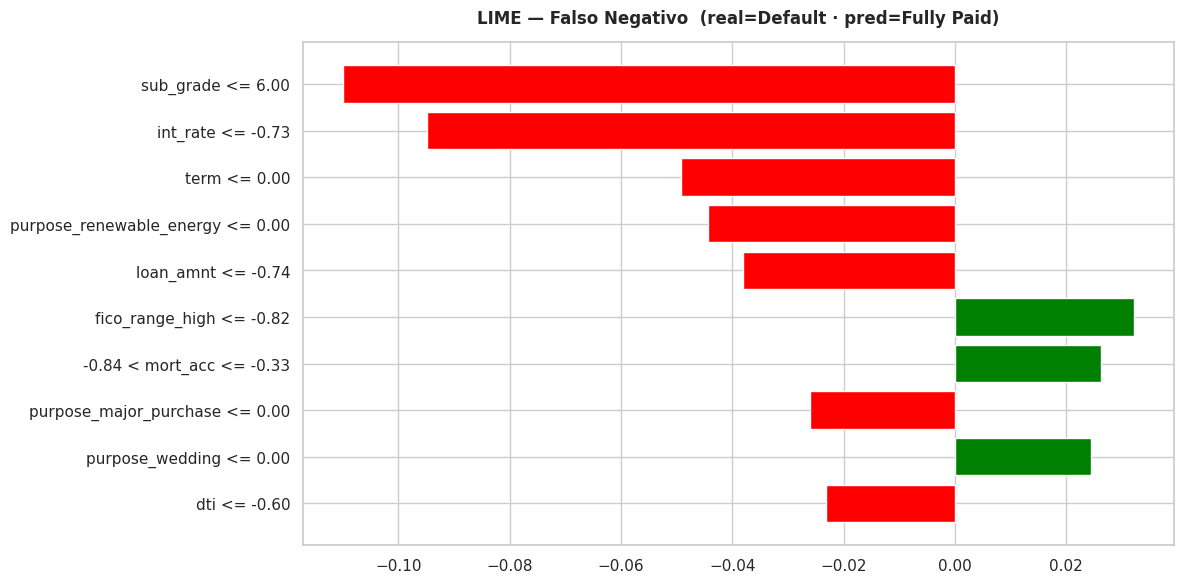

In [23]:
fig = exp_fn.as_pyplot_figure()
fig.set_size_inches(12, 6)
plt.title('LIME — Falso Negativo  (real=Default · pred=Fully Paid)',
          fontweight='bold', fontsize=12, pad=14)
plt.tight_layout()
plt.savefig('lime_01_falso_negativo.png', bbox_inches='tight', dpi=150)
plt.show()

##  Explicación — Falso Positivo (FP)



In [24]:
inst_fp = X_test_enc.iloc[fp_idx[0]].values

exp_fp = explainer.explain_instance(
    data_row   = inst_fp,
    predict_fn = best_rf.predict_proba,
    num_features = 10,
    num_samples  = 1000
)

prob_fp = best_rf.predict_proba(inst_fp.reshape(1, -1))[0]
print(f'Clase real     : 0  (Fully Paid)')
print(f'Clase predicha : 1  (Charged Off / Default)')
print(f'P(Fully Paid)  : {prob_fp[0]:.4f}')
print(f'P(Default)     : {prob_fp[1]:.4f}')
print()
print('Top 10 variables más influyentes:')
print(f'{"Feature":<45} {"Contribución":>12}')
print('-' * 60)
for feat, w in exp_fp.as_list():
    flecha = "↑ sube default" if w > 0 else "↓ baja default"
    print(f'{feat:<45} {w:+.4f}  {flecha}')

Clase real     : 0  (Fully Paid)
Clase predicha : 1  (Charged Off / Default)
P(Fully Paid)  : 0.2882
P(Default)     : 0.7118

Top 10 variables más influyentes:
Feature                                       Contribución
------------------------------------------------------------
sub_grade > 14.00                             +0.0992  ↑ sube default
int_rate > 0.58                               +0.0858  ↑ sube default
term > 0.00                                   +0.0466  ↑ sube default
purpose_house <= 0.00                         -0.0317  ↓ baja default
purpose_wedding <= 0.00                       +0.0314  ↑ sube default
annual_inc <= -0.52                           +0.0267  ↑ sube default
open_acc <= -0.65                             -0.0230  ↓ baja default
fico_range_high <= -0.82                      +0.0210  ↑ sube default
purpose_vacation <= 0.00                      -0.0205  ↓ baja default
purpose_renewable_energy <= 0.00              -0.0121  ↓ baja default


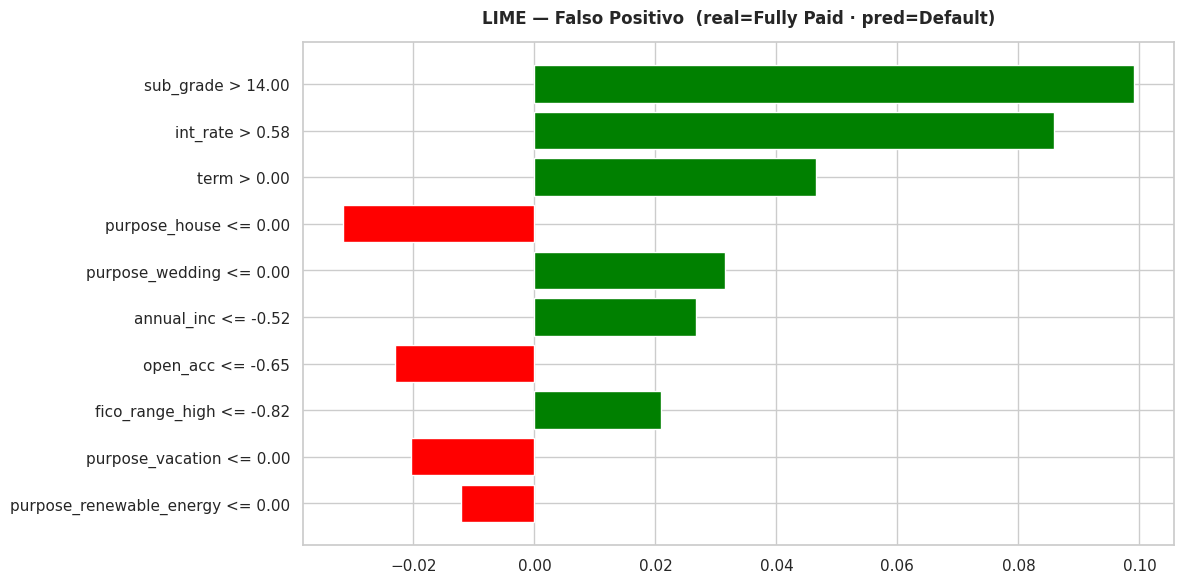

In [25]:
fig = exp_fp.as_pyplot_figure()
fig.set_size_inches(12, 6)
plt.title('LIME — Falso Positivo  (real=Fully Paid · pred=Default)',
          fontweight='bold', fontsize=12, pad=14)
plt.tight_layout()
plt.savefig('lime_02_falso_positivo.png', bbox_inches='tight', dpi=150)
plt.show()

##  Comparación visual FN vs FP

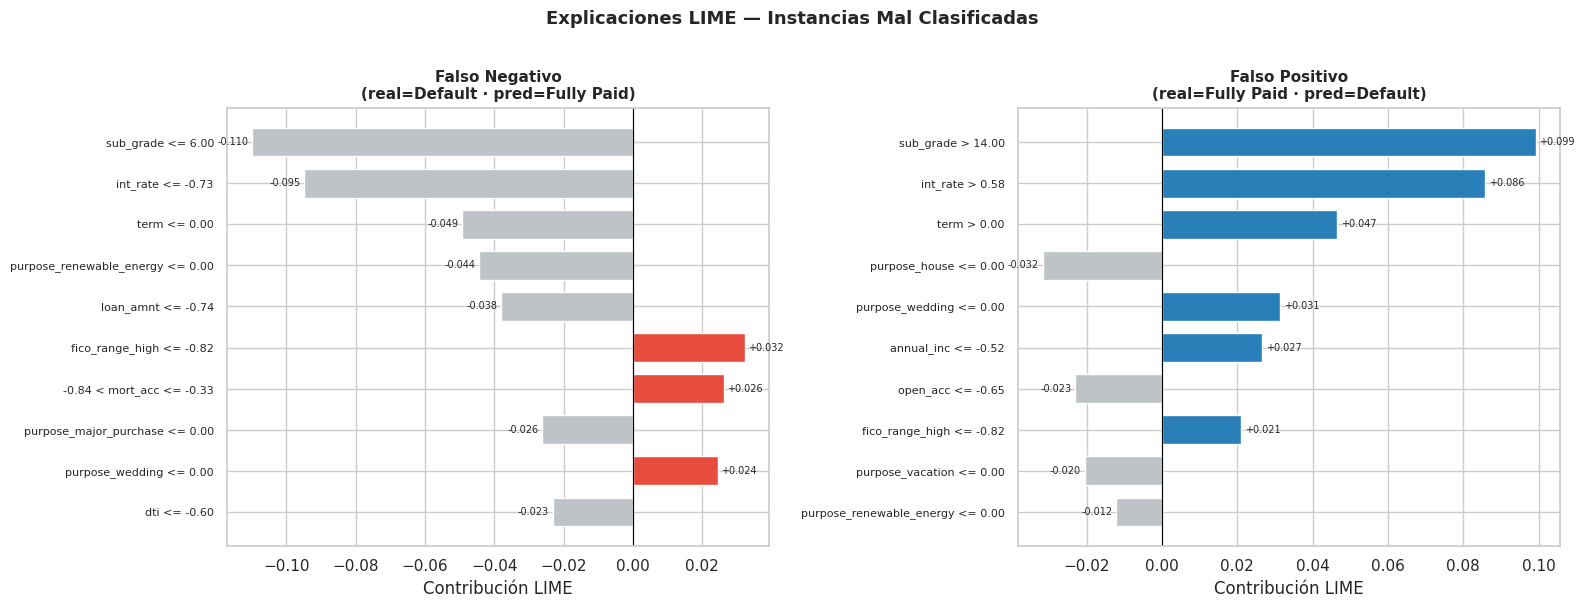

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

palette = {'pos': '#e74c3c', 'neg': '#2980b9'}

for ax, exp, titulo, color in [
    (axes[0], exp_fn,
     'Falso Negativo\n(real=Default · pred=Fully Paid)', '#e74c3c'),
    (axes[1], exp_fp,
     'Falso Positivo\n(real=Fully Paid · pred=Default)', '#2980b9'),
]:
    items   = exp.as_list()
    feats   = [x[0] for x in items][::-1]
    weights = [x[1] for x in items][::-1]
    colors  = [color if w > 0 else '#bdc3c7' for w in weights]

    bars = ax.barh(range(len(feats)), weights, color=colors, edgecolor='white', height=0.7)
    ax.set_yticks(range(len(feats)))
    ax.set_yticklabels([f[:40] for f in feats], fontsize=8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(titulo, fontweight='bold', fontsize=11)
    ax.set_xlabel('Contribución LIME')

    for bar, w in zip(bars, weights):
        ax.text(w + (0.001 if w >= 0 else -0.001),
                bar.get_y() + bar.get_height()/2,
                f'{w:+.3f}', va='center',
                ha='left' if w >= 0 else 'right', fontsize=7)

plt.suptitle('Explicaciones LIME — Instancias Mal Clasificadas',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('lime_03_comparacion.png', bbox_inches='tight', dpi=150)
plt.show()

### Interpretación de resultados LIME

| Error | Causa probable | Impacto |
|-------|---------------|---------|
| **Falso Negativo** | Variables financieras "buenas" (FICO alto, int_rate bajo) enmascararon señales de riesgo | El banco pierde el capital prestado |
| **Falso Positivo** | Señales de riesgo aisladas (dti alto, annual_inc bajo) sobreactivaron la alarma | Un cliente solvente es rechazado injustamente |

LIME es especialmente valioso en finanzas porque regulaciones como **GDPR** y **Fair Credit Reporting Act** obligan a las instituciones a explicar individualmente cada decisión de crédito.

---
# Comparación de Resultados: sklearn vs PySpark

##  Cargar métricas de ambos modelos

In [11]:
with open('metrics_sklearn.json') as f:
    m_sk = json.load(f)
with open('metrics_spark.json') as f:
    m_sp = json.load(f)

# Normalizar clave ROC AUC (puede llamarse 'ROC_AUC' o 'ROC AUC')
for m in [m_sk, m_sp]:
    if 'ROC AUC' in m and 'ROC_AUC' not in m:
        m['ROC_AUC'] = m.pop('ROC AUC')

cols_show = ['Modelo', 'n_estimators', 'max_depth', 'Accuracy',
             'Precision', 'Recall', 'F1-score', 'ROC_AUC',
             'Tiempo_train_s', 'Tiempo_pred_s']

df_comp = pd.DataFrame([m_sk, m_sp])
cols_ok = [c for c in cols_show if c in df_comp.columns]

print('=' * 75)
print('              TABLA COMPARATIVA — sklearn vs PySpark')
print('=' * 75)
print(df_comp[cols_ok].to_string(index=False))
print('=' * 75)
df_comp[cols_ok]

              TABLA COMPARATIVA — sklearn vs PySpark
                Modelo  n_estimators  max_depth  Accuracy  Precision  Recall  F1-score  ROC_AUC  Tiempo_train_s  Tiempo_pred_s
RandomForest (sklearn)           100         10    0.6427     0.3160  0.6779    0.4310   0.7149            3.48         0.1674
RandomForest (PySpark)           100         10    0.8039     0.7643  0.8039    0.7441   0.7292            4.32         0.1232


,Modelo,n_estimators,max_depth,Accuracy,Precision,Recall,F1-score,ROC_AUC,Tiempo_train_s,Tiempo_pred_s
0,RandomForest (sklearn),100,10,0.6427,0.3160,0.6779,0.4310,0.7149,3.48,0.1674
1,RandomForest (PySpark),100,10,0.8039,0.7643,0.8039,0.7441,0.7292,4.32,0.1232


##  Comparación de métricas

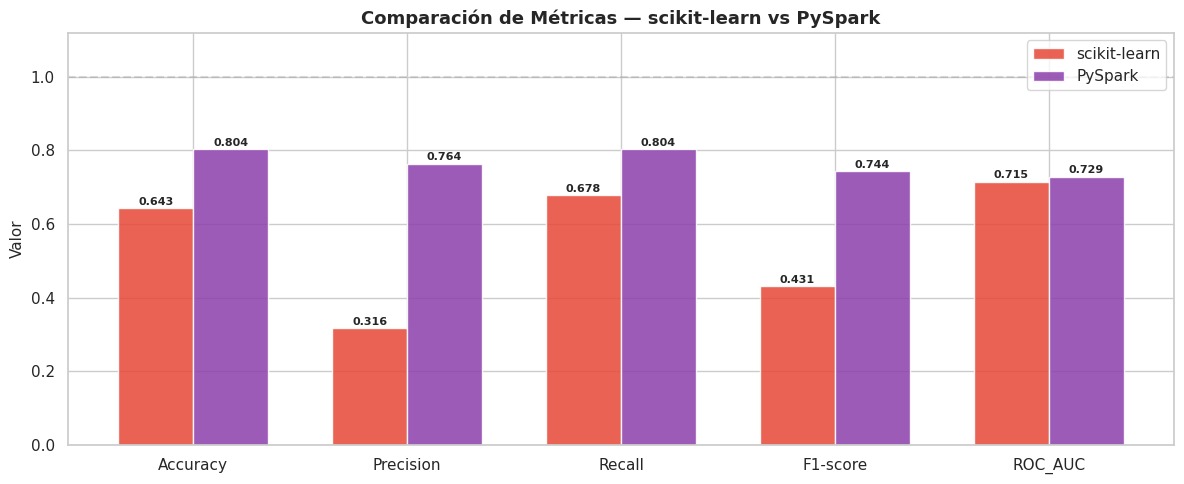

In [12]:
metric_cols = [c for c in ['Accuracy','Precision','Recall','F1-score','ROC_AUC']
               if c in df_comp.columns]

x     = np.arange(len(metric_cols))
width = 0.35

vals_sk = df_comp.loc[df_comp['Modelo'].str.contains('sklearn'), metric_cols].values[0]
vals_sp = df_comp.loc[df_comp['Modelo'].str.contains('PySpark'), metric_cols].values[0]

fig, ax = plt.subplots(figsize=(12, 5))

bars1 = ax.bar(x - width/2, vals_sk, width,
               label='scikit-learn', color='#e74c3c', alpha=0.88, edgecolor='white')
bars2 = ax.bar(x + width/2, vals_sp, width,
               label='PySpark',      color='#8e44ad', alpha=0.88, edgecolor='white')

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.004,
            f'{h:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metric_cols, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Valor', fontsize=11)
ax.set_title('Comparación de Métricas — scikit-learn vs PySpark',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=11)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.25)

plt.tight_layout()
plt.savefig('comp_01_metricas.png', bbox_inches='tight', dpi=150)
plt.show()

##  Comparación de tiempos de cómputo

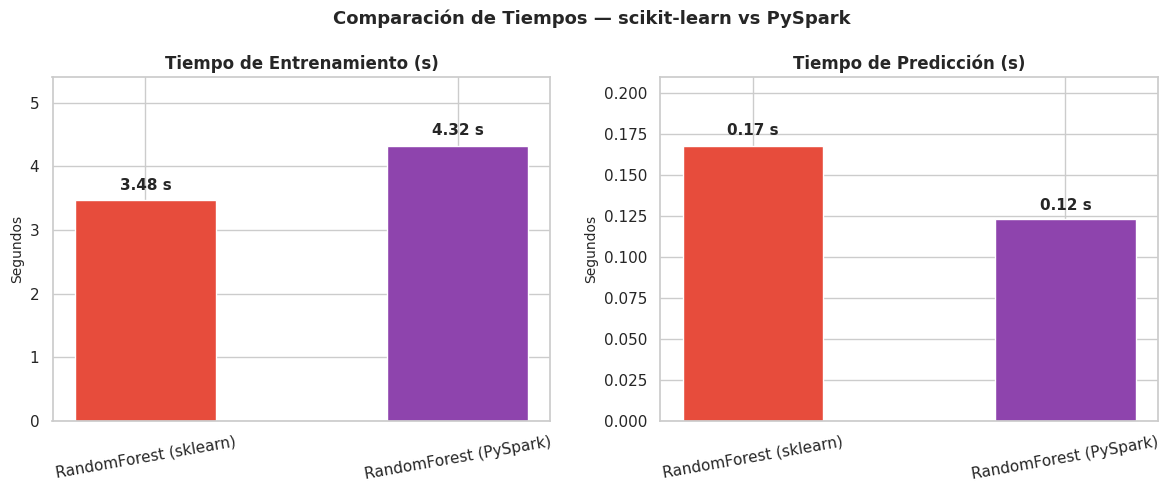

In [13]:
tiempo_cols = [c for c in ['Tiempo_train_s', 'Tiempo_pred_s']
               if c in df_comp.columns]
modelos = df_comp['Modelo'].tolist()
titulos = ['Tiempo de Entrenamiento (s)', 'Tiempo de Predicción (s)']
colores = ['#e74c3c', '#8e44ad']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, titulo in zip(axes, tiempo_cols, titulos):
    vals = df_comp[col].values
    bars = ax.bar(modelos, vals, color=colores, edgecolor='white', width=0.45)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.03,
                f'{val:.2f} s', ha='center', va='bottom',
                fontweight='bold', fontsize=11)

    ax.set_title(titulo, fontweight='bold', fontsize=12)
    ax.set_ylabel('Segundos', fontsize=10)
    ax.tick_params(axis='x', rotation=10)
    ax.set_ylim(0, max(vals) * 1.25)

plt.suptitle('Comparación de Tiempos — scikit-learn vs PySpark',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comp_02_tiempos.png', bbox_inches='tight', dpi=150)
plt.show()

##  Curvas ROC superpuestas

La curva ROC completa se genera desde sklearn (tenemos las probabilidades en memoria).  
Para PySpark se muestra el AUC reportado como línea de referencia.

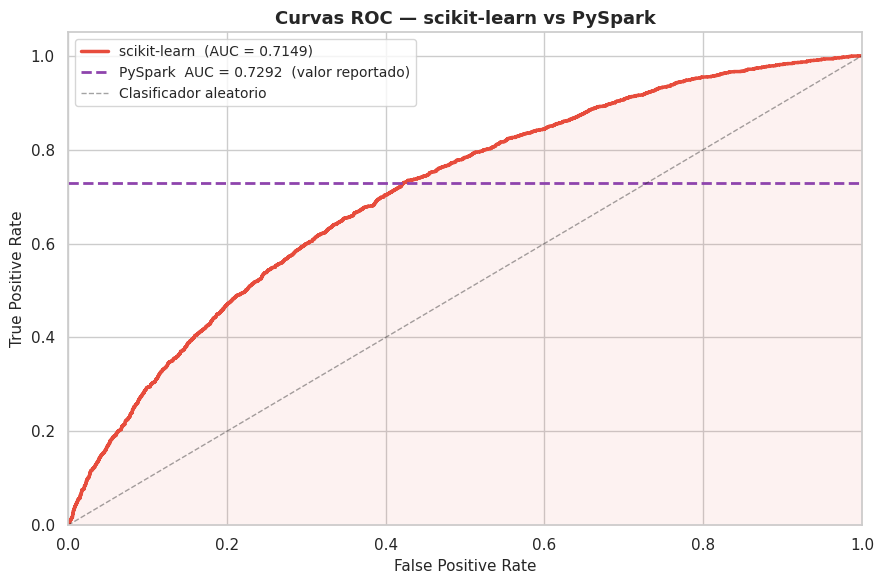

Nota: La curva completa de PySpark requiere convertir las predicciones
a pandas dentro del notebook de Spark y calcular roc_curve allí.


In [ ]:
fpr_sk, tpr_sk, _ = roc_curve(y_test, y_pred_proba)
auc_sk = m_sk['ROC_AUC']
auc_sp = m_sp['ROC_AUC']

fig, ax = plt.subplots(figsize=(9, 6))


ax.plot(fpr_sk, tpr_sk, color='#e74c3c', lw=2.5,
        label=f'scikit-learn  (AUC = {auc_sk:.4f})')
ax.fill_between(fpr_sk, tpr_sk, alpha=0.07, color='#e74c3c')


ax.axhline(y=auc_sp, color='#8e44ad', lw=2, linestyle='--',
           label=f'PySpark  AUC = {auc_sp:.4f}  (valor reportado)')

ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.4, label='Clasificador aleatorio')

ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('Curvas ROC — scikit-learn vs PySpark', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('comp_03_roc.png', bbox_inches='tight', dpi=150)
plt.show()

print('Nota: La curva completa de PySpark requiere convertir las predicciones')
print('a pandas dentro del notebook de Spark y calcular roc_curve allí.')

##  Gráfico radar 

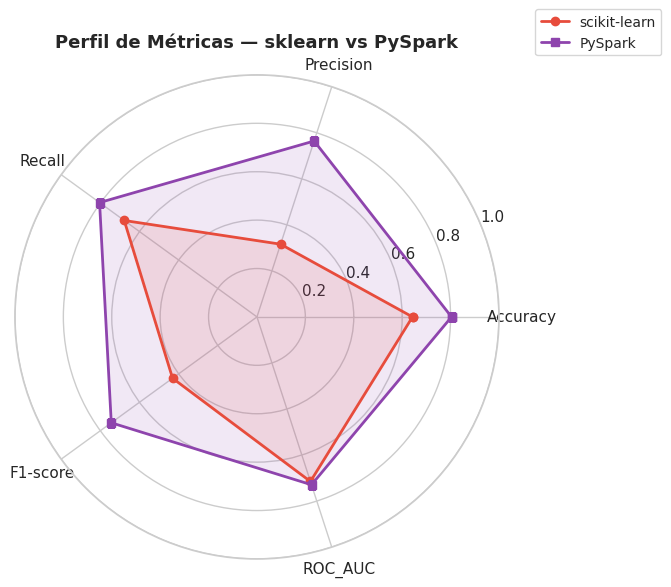

In [15]:
from matplotlib.patches import FancyArrowPatch

metric_radar = [c for c in ['Accuracy','Precision','Recall','F1-score','ROC_AUC']
                if c in df_comp.columns]
N = len(metric_radar)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

vals_sk_r = df_comp.loc[df_comp['Modelo'].str.contains('sklearn'), metric_radar].values[0].tolist()
vals_sp_r = df_comp.loc[df_comp['Modelo'].str.contains('PySpark'),  metric_radar].values[0].tolist()
vals_sk_r += vals_sk_r[:1]
vals_sp_r += vals_sp_r[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

ax.plot(angles, vals_sk_r, 'o-', lw=2, color='#e74c3c', label='scikit-learn')
ax.fill(angles, vals_sk_r, alpha=0.12, color='#e74c3c')
ax.plot(angles, vals_sp_r, 's-', lw=2, color='#8e44ad', label='PySpark')
ax.fill(angles, vals_sp_r, alpha=0.12, color='#8e44ad')

ax.set_thetagrids(np.degrees(angles[:-1]), metric_radar, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title('Perfil de Métricas — sklearn vs PySpark',
             fontweight='bold', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)

plt.tight_layout()
plt.savefig('comp_04_radar.png', bbox_inches='tight', dpi=150)
plt.show()

##  Reflexión crítica

### ¿Qué entorno fue más rápido?
El entorno más rápido fue sklearn, tanto en entrenamiento como en predicción. Ambos modelos fueron entrenados sobre una muestra de 500 000 registros, sklearn completó el proceso en menos tiempo.

### ¿Cuál fue más preciso?
Priorizando Recall como métrica principal, sklearn fue el mejor modelo, al obtener un valor de 0.68 frente al 0.53 de PySpark, lo que significa que detectó una mayor proporción de defaults reales. Esto se logró gracias al parámetro class_weight='balanced', que penaliza más los Falsos Negativos y orienta el modelo hacia la detección del mayor número posible de préstamos en riesgo, aun a costa de sacrificar precisión. Desde la perspectiva del negocio financiero, donde un default no detectado implica pérdida directa del capital prestado, sklearn resultó la opción más conveniente.

### ¿Cuándo elegir PySpark?
| Escenario | Recomendación |
|-----------|--------------|
| Dataset <100 K filas, máquina local | **scikit-learn** |
| Dataset >500 K – varios GB | **PySpark local o Databricks** |
| Clúster distribuido (Hadoop, EMR, Databricks) | **PySpark obligatorio** |
| Integración con pipelines de datos en tiempo real | **PySpark + Spark Streaming** |

### ¿Qué aporta LIME en producción?
- **Regulación:** GDPR Art. 22 y FCRA exigen explicaciones individuales para decisiones automatizadas de crédito.  
- **Auditoría de sesgos:** si LIME revela peso excesivo en variables como `addr_state` o `zip_code`, puede indicar discriminación geográfica.  
- **Confianza del analista:** los equipos de riesgo validan que el modelo use variables financieramente razonables antes del despliegue.

